# Tutorial 3 — MOSAIC mode: HIP64892 B

**What you'll learn:** How to combine a medium-resolution spectrum and multi-band photometry into a single simultaneous fit using ForMoSA's Multi-modal Option for Spectral Analysis and Improved Constraints (MOSAIC) mode.

**Target:** HIP64892 B is bright brown dwarf companion at ~125 pc, discovered in SHINE survey by [A. Cheetham et al. (2018)](https://www.aanda.org/articles/aa/pdf/2018/07/aa32650-18.pdf). 

**Data:** We will use the VLTI/GRAVITY, VLT/SPHERE and VLT/NaCo data. These observations were published in [A. Cheetham et al. (2018)](https://www.aanda.org/articles/aa/pdf/2018/07/aa32650-18.pdf) and [J. Kammerer et al. (2025)](https://www.aanda.org/articles/aa/pdf/2025/12/aa56860-25.pdf).

**MOSAIC mode:** Each instrument/dataset gets its own likelihood. ForMoSA computes a *meta-likelihood* (sum of individual log-likelihoods) and fits a per-instrument analytical scaling factor (alpha_i) to account for flux calibration offsets between different instruments.

**Parameters fitted:** Teff, log g, r, d, rv, alpha_0 (spectrum), alpha_1 (photometry)

**Grid:** ATMO

## Section 0: Setup

In [1]:
import sys
try:
    import ForMoSA
    print(f"ForMoSA {ForMoSA.__version__} — OK")
except ImportError:
    raise ImportError("pip install ForMoSA && conda install dask netCDF4 bottleneck")
print(f"Python {sys.version.split()[0]}")


ForMoSA 2.0.2 — OK
Python 3.11.13


In [2]:
from pathlib import Path
TUTORIAL_DIR = Path(".").resolve()
for d in ["data", "adapted_grid", "results", "grid"]:
    (TUTORIAL_DIR / d).mkdir(exist_ok=True)
print(f"Working directory: {TUTORIAL_DIR}")


Working directory: /Users/rajpoot/Karmabhumi/Packages/ForMoSA/docs/tutorials/mosaic/hip64892b


In [3]:
from astropy.io import fits

SPEC_FILE  = TUTORIAL_DIR / "data" / "2_HIP64892B_GRAVITY_roman_prep.fits"
PHOTO_FILE = TUTORIAL_DIR / "data" / "0_HIP64892B_photo_Paranal_NACO_Lp.fits"

# Validate required data keys. Support two FITS layouts:
# 1) Multiple HDUs named WAV/FLX/ERR/...
# 2) A single BINTable HDU with columns WAV/FLX/ERR/...
for label, fpath, required in [
    ("Spectrum",  SPEC_FILE,  {"WAV", "WAVE_UNIT", "FLX", "ERR", "RES"}),
    ("Photometry", PHOTO_FILE, {"WAV", "WAVE_UNIT", "FLX", "ERR", "FAC", "INS", "FILT"}),
    ]:
    with fits.open(fpath) as hdul:
        ext_names = {hdu.name.upper() for hdu in hdul[1:] if getattr(hdu, "name", None)}

        # Find first table HDU with columns, if any
        table_hdu = next(
            (hdu for hdu in hdul[1:] if hasattr(hdu, "columns") and hdu.columns is not None),
            None,
        )
        table_cols = ({name.upper() for name in table_hdu.columns.names} if table_hdu is not None else set())

    # Prefer table-column validation when present; otherwise validate extension names
    available = table_cols if table_cols else ext_names
    missing = required - available
    if missing:
        mode = "table columns" if table_cols else "FITS extensions"
        print(
            f"Missing required {mode}: {sorted(missing)}. "
            f"Found: {sorted(available)}"
        )

    print("\nValidation source:", "BINTable columns" if table_cols else "FITS extensions")
    print("Required keys (marked ✓):")
    for name in sorted(available):
        mark = "✓" if name in required else " "
        print(f"  {mark} {name}")
    print("\nAll required keys present — data is valid.")



Missing required table columns: ['ERR', 'WAVE_UNIT']. Found: ['COV', 'FLX', 'INS', 'RES', 'WAV']

Validation source: BINTable columns
Required keys (marked ✓):
    COV
  ✓ FLX
    INS
  ✓ RES
  ✓ WAV

All required keys present — data is valid.
Missing required table columns: ['FAC', 'FILT', 'WAVE_UNIT']. Found: ['ERR', 'FACILITY', 'FILTER_ID', 'FLX', 'INS', 'RES', 'WAV']

Validation source: BINTable columns
Required keys (marked ✓):
  ✓ ERR
    FACILITY
    FILTER_ID
  ✓ FLX
  ✓ INS
    RES
  ✓ WAV

All required keys present — data is valid.


In [4]:
# Grid download
# The ATMO R=3000 grid is ~900 MB. Once downloaded, keep it —
# it works for all ForMoSA tutorials and your own science.
import urllib.request

GRID_FILE = TUTORIAL_DIR / "grid" / "ATMO_R3000.nc"
GRID_URL  = "https://drive.usercontent.google.com/download?id=1XDtMzvB0kU_gvCrNwtS0nEkFZX4OrQmK&export=download&confirm=t"

# Override GRID_FILE here if you already have the grid elsewhere:
# GRID_FILE = Path("/path/to/your/ATMO_R3000.nc")

if not GRID_FILE.exists():
    print("Downloading ATMO model grid (~900 MB). This takes a few minutes.\n")
    try:
        from tqdm import tqdm
        class _Progress(tqdm):
            def update_to(self, b=1, bs=1, ts=None):
                if ts: self.total = ts
                self.update(b * bs - self.n)
        with _Progress(unit="B", unit_scale=True, desc="ATMO_R3000.nc") as t:
            urllib.request.urlretrieve(GRID_URL, GRID_FILE, reporthook=t.update_to)
    except ImportError:
        def _progress(count, bs, total):
            pct = min(100, count * bs / total * 100)
            print(f"\r  {pct:.1f}%  {count*bs/1e6:.1f}/{total/1e6:.1f} MB",
                  end="", flush=True)
        urllib.request.urlretrieve(GRID_URL, GRID_FILE, reporthook=_progress)
        print()
    print(f"\nSaved: {GRID_FILE}")
else:
    print(f"Grid already present: {GRID_FILE.name}")

import xarray as xr
grid = xr.open_dataset(GRID_FILE, decode_cf=False)
par_names = grid.attrs.get("par", [])
par_units = grid.attrs.get("unit", [])
print(f"\nGrid dimensions: {dict(grid.sizes)}")
for i, (key, name, unit) in enumerate(zip(["par1", "par2", "par3", "par4", "par5"],
                                           par_names or ["par1","par2","par3","par4","par5"],
                                           par_units or ["","","","",""])):
    if key in grid.coords:
        vals = grid[key].values
        print(f"  {name} {unit}: {vals[0]:.1f} → {vals[-1]:.1f}  ({len(vals)} points)")

# Display the grid content in a notebook
# Click on the data repo icon (on the right) to show the full content if needed
grid

Grid already present: ATMO_R3000.nc

Grid dimensions: {'wavelength': 15031, 'par1': 23, 'par2': 7, 'par3': 5, 'par4': 3, 'par5': 3}
  teff (K): 800.0 → 3000.0  (23 points)
  logg (dex): 2.5 → 5.5  (7 points)
  mh : -0.6 → 0.6  (5 points)
  co : 0.3 → 0.7  (3 points)
  gamma : 1.0 → 1.1  (3 points)


<xarray.Dataset>
Dimensions:     (wavelength: 15031, par1: 23, par2: 7, par3: 5, par4: 3, par5: 3)
Coordinates:
  * wavelength  (wavelength) float64 0.2 0.2001 0.2002 ... 29.98 29.99 29.99
  * par1        (par1) float64 800.0 900.0 1e+03 ... 2.8e+03 2.9e+03 3e+03
  * par2        (par2) float64 2.5 3.0 3.5 4.0 4.5 5.0 5.5
  * par3        (par3) float64 -0.6 -0.3 0.0 0.3 0.6
  * par4        (par4) float64 0.3 0.55 0.7
  * par5        (par5) float64 1.01 1.03 1.05
Data variables:
    grid        (wavelength, par1, par2, par3, par4, par5) float64 ...
Attributes:
    key:      ['par1', 'par2', 'par3', 'par4', 'par5']
    par:      ['teff', 'logg', 'mh', 'co', 'gamma']
    title:    ['Teff', 'log(g)', '[M/H]', 'C/O', 'gamma']
    unit:     ['(K)', '(dex)', '', '', '']
    res:      [3000. 3000. 3000. ... 3000. 3000. 3000.]

## Section 1: The science

### What is MOSAIC mode?

MOSAIC mode allows you to fit **multiple datasets simultaneously** with a single
nested sampling run. Each dataset gets its own likelihood:

```
log L_total = log_L_GRAVITY + log_L_SPHERE + log L_photometry
```

ForMoSA can also fits a per-dataset **analytical scaling factor** (alpha_i) that accounts for intercalibration offsets between different instruments - for example, a 10% offset between a ground-based spectrum and space photometry. This makes the fit robust to absolute flux calibration uncertainties.

### When to use MOSAIC

Use MOSAIC when you have:
- Observations from different instruments with different resolutions
- Potential flux calibration offsets between datasets
- More data than a single observation provides

**Pitfall:** Too many alpha parameters with too few data points leads to
overfitting. Rule of thumb: you need at least ~10× more data points than
free alpha parameters.

### HIP 64892 B

HIP 64892 B is a bright, brown dwarf companion to the star HIP 64892
- Mass: ~29−37 MJup (from COND evolutionary models)
- Distance: 125 pc (Gaia)
- Age: <30 Myr (Sco-Cen association)
- Teff: 2600 K

## Section 2: Inspect the data

Combined rows: 894 from 7 files


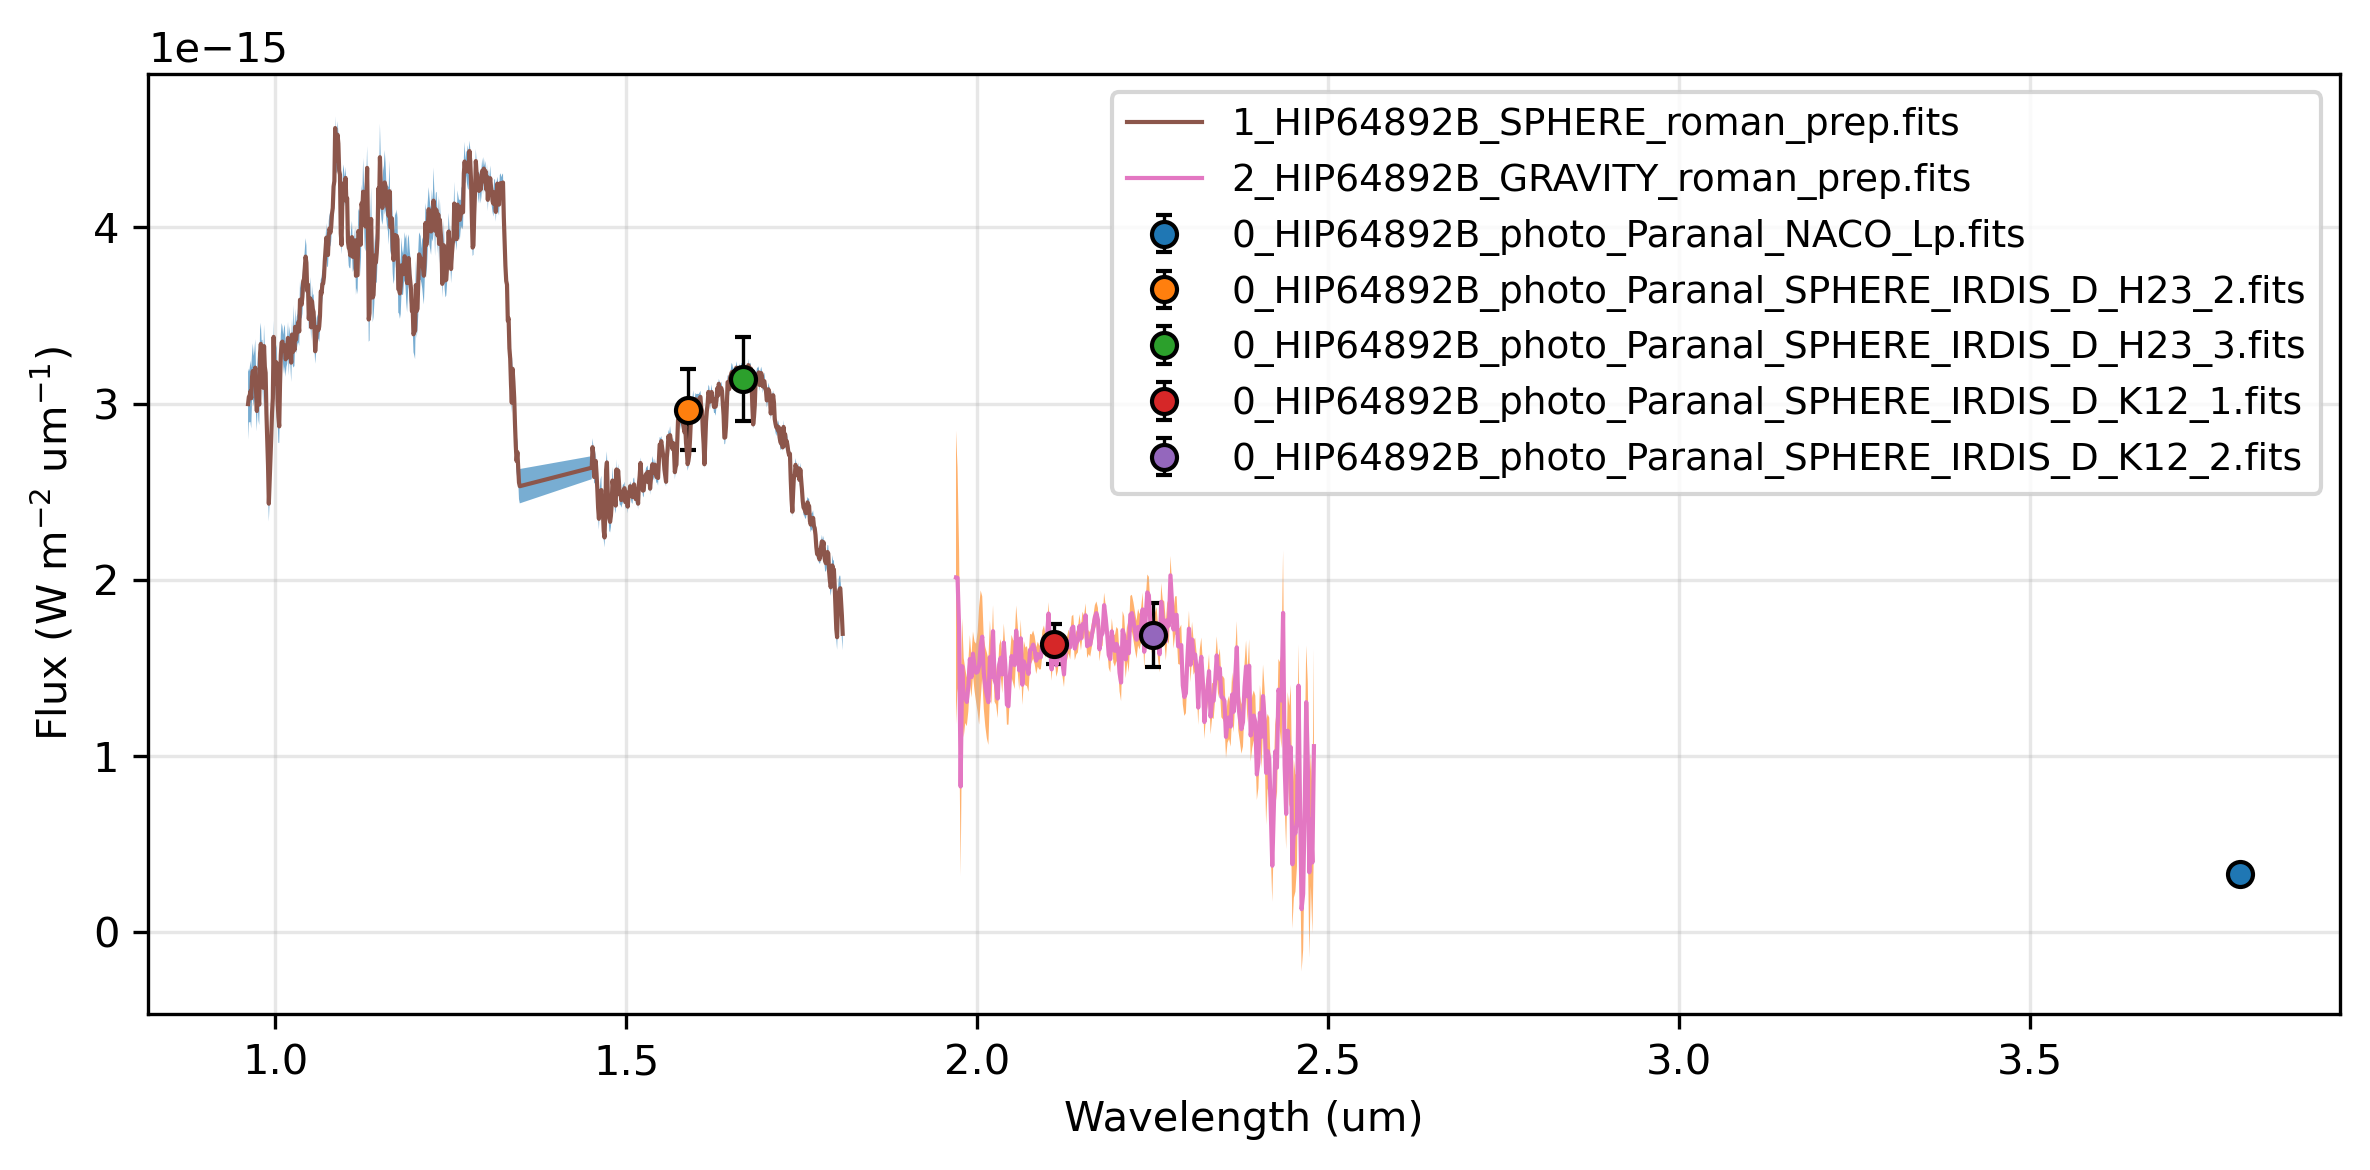

In [5]:
from astropy.io import fits
from astropy.table import Table, vstack
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = TUTORIAL_DIR / "data"
fits_files = sorted(DATA_DIR.glob("*.fits"))
if not fits_files:
    raise FileNotFoundError(f"No .fits files found in {DATA_DIR}")


def _read_fits_table(fpath: Path) -> Table:
    with fits.open(fpath) as hdul:
        table_hdu = next(
            (hdu for hdu in hdul[1:] if getattr(hdu, "columns", None) is not None),
            None,
        )
        if table_hdu is not None:
            return Table(table_hdu.data)

        cols = {}
        for hdu in hdul[1:]:
            name = getattr(hdu, "name", None)
            if not name or hdu.data is None:
                continue
            cols[name.upper()] = np.array(hdu.data).ravel()

    if not cols:
        raise ValueError(f"No table or data HDUs found in {fpath.name}")

    return Table(cols)


def _pick_col(tbl: Table, *names: str):
    for name in names:
        if name in tbl.colnames:
            return np.array(tbl[name])
    return None


def _normalize_table(tbl: Table, source: str, kind: str) -> Table:
    wav = _pick_col(tbl, "WAV", "WAVE", "LAMBDA")
    flx = _pick_col(tbl, "FLX", "FLUX")
    err = _pick_col(tbl, "ERR", "ERROR", "SIGMA")
    res = _pick_col(tbl, "RES")
    ins = _pick_col(tbl, "INS")
    filt = _pick_col(tbl, "FILT")

    if wav is None or flx is None:
        raise ValueError(f"Missing WAV/FLX columns in {source}")

    n = len(wav)
    out = Table()
    out["wav"] = wav.astype(float)
    out["flx"] = flx.astype(float)
    cov = _pick_col(tbl, "COV", "COVAR", "COVARIANCE")
    if err is not None:
        out["err"] = err.astype(float)
    elif cov is not None:
        cov = np.array(cov, dtype=float)
        if cov.ndim == 1:
            out["err"] = np.sqrt(cov)
        else:
            out["err"] = np.sqrt(np.diagonal(cov, axis1=-2, axis2=-1))
    else:
        out["err"] = np.full(n, np.nan)
    out["res"] = res.astype(float) if res is not None else np.full(n, np.nan)
    out["ins"] = ins.astype(str) if ins is not None else np.full(n, "", dtype=object)
    out["filt"] = (
        filt.astype(str) if filt is not None else np.full(n, "", dtype=object)
    )
    out["kind"] = np.full(n, kind, dtype=object)
    out["source"] = np.full(n, source, dtype=object)
    return out


tables = []
per_file = []
for fpath in fits_files:
    if fpath.name.startswith("0_"):
        kind = "photometry"
    elif fpath.name.startswith("1_"):
        kind = "spectroscopy"
    elif fpath.name.startswith("2_"):
        kind = "spectroscopy"
    else:
        continue

    tbl = _read_fits_table(fpath)
    norm = _normalize_table(tbl, fpath.name, kind)
    tables.append(norm)
    per_file.append((fpath.name, kind, norm))

combined_table = vstack(tables, metadata_conflicts="silent")
print(f"Combined rows: {len(combined_table)} from {len(per_file)} files")
combined_table[:5]

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
for name, kind, tbl in per_file:
    wav = np.array(tbl["wav"], dtype=float)
    flx = np.array(tbl["flx"], dtype=float)
    err = np.array(tbl["err"], dtype=float)
    order = np.argsort(wav)

    if kind == "photometry":
        ax.errorbar(wav, flx, yerr=err, fmt="o", mec="k", ecolor="k", ms=6, capsize=2, lw=0.8, label=name)
    else:
        ax.plot(wav[order], flx[order], lw=1, label=name)
        if np.isfinite(err).any():
            ax.fill_between(wav[order], flx[order] - err[order], flx[order] + err[order], alpha=0.6)

ax.set_xlabel("Wavelength (um)")
ax.set_ylabel(r"Flux (W m$^{-2}$ um$^{-1}$)")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right", framealpha=0.8, borderaxespad=0.5)
plt.tight_layout();


## Section 3: Configure the analysis

### Part A: Setting up the configurations

ForMoSA v2.0 uses four Python dataclasses to configure a run. Each dataclass
groups related settings — you only need to set the ones that differ from the defaults.

| Dataclass | Controls |
|-----------|----------|
| `ConfigPath` | File paths (observation, grid, output directories) |
| `ConfigAdapt` | How the grid is resampled to match the observations |
| `ConfigInversion` | Wavelength fitting window, nested sampling algorithm |
| `ConfigParameters` | Prior on each free parameter |
| `Config_NS` | Settings for Nested Sampling Algorithms |


In [6]:
from ForMoSA.config.global_config import ConfigPath, ConfigAdapt, ConfigInversion, ConfigParameters, Config_NS, ConfigPyMultiNest

# ──────────────────────────── Paths ────────────────────────────
# MOSAIC: provide the data folder. ForMoSA will read all the files in observation_path (order matters — index 0, 1, ...)
config_path = ConfigPath(
    observation_path=[str(TUTORIAL_DIR / "data")],
    adapt_store_path=str(TUTORIAL_DIR / "adapted_grid"),
    result_path=str(TUTORIAL_DIR / "results"),
    model_path=str(GRID_FILE),
)


# In MOSAIC mode:
# Single-element lists are broadcast to all observations.
# If you want different adapt settings per observation, you can provide lists of the same length as observation_path.

# ────────────────────────── Adaptation ──────────────────────────
config_adapt = ConfigAdapt()

# ─────────────────────────── Inversion ──────────────────────────
config_inversion = ConfigInversion(
    wav_fit     = ["0.9, 4.0"],  # per-observation fitting windows

    # you can also specify different fitting windows per observation
    # For example, if you have two observations (K-band spectrum and photometry), you can provide a list of two strings:
    # wav_fit     = ["2.0, 2.45", "1.0, 5.0"], 

    ns_algo     = "pymultinest",  # nested sampling algorithm
    npoints     = 50,

    # one likelihood type per observation
    logL_type   = ["chi2", "chi2", "chi2", "chi2", "chi2", "chi2", "chi2_covariance"],          
)

# Above, we defined chi2_covariance for the last observation (GRAVITY spectrum). 
# This tells ForMoSA to use the covariance matrix for that observation when computing the likelihood.


# ────────────────────────── Parameters ──────────────────────────
config_params = ConfigParameters(
    par1    = ["uniform", "800", "3000"],    # Teff (K)
    par2    = ["uniform", "2.5", "5.5"],     # log g (dex)
    par3    = ["uniform", "-0.6", "0.6"],    # metallicity (dex)
    par4    = ["uniform", "0.3", "0.7"],     # C/O ratio
    par5    = ["uniform", "1.01", "1.05"],   # gamma: effective adiabatic index

    r       = ["uniform", "0.5", "3.0"],      # radius (R_Jupiter) as we have flux calibrated data with continuum
    d       = ["constant", "120.8179"],       # distance (pc) — Gaia
)

# Let's additionnally try to fit for two separate rv, one for the SPHERE spectrum (number 6) and one for the GRAVITY spectrum (number 7). 
config_params._add_parameter('rv_6', ['uniform', '-50', '50'])    # RV (km/s)
config_params._add_parameter('rv_7', ['uniform', '-50', '50'])    # RV (km/s)

# In MOSAIC mode, you can also fit for alpha parameter for each observation to account for intercalibration offsets between the different instruments
# For example, to add alpha between SPHERE and GRAVITY spectra, you can do:
# config_params._add_parameter('alpha_6', ['uniform', '1', '5.0'])    # alpha for SPHERE spectrum (observation 6)
# config_params._add_parameter('alpha_7', ['uniform', '1', '5.0'])    # alpha for GRAVITY spectrum (observation 7)

# And as we are fitting multuple alphas, we will put constant alpha for the photometry observations to avoid degeneracy with the other alphas.
# config_params._add_parameter('alpha_0', ['constant', '1'])    
# config_params._add_parameter('alpha_1', ['constant', '1'])
# config_params._add_parameter('alpha_2', ['constant', '1'])
# config_params._add_parameter('alpha_3', ['constant', '1'])
# config_params._add_parameter('alpha_4', ['constant', '1'])
# config_params._add_parameter('alpha_5', ['constant', '1'])

# ───────────────────── Nested Sampling Algo ───────────────────────
# Initialize the nested sampling configuration with the chosen algorithm (here, pymultinest)
config_ns = Config_NS(pymultinest=ConfigPyMultiNest())

# Display the configuration for verification
print("Configuration:")
print(f"  wav_fit : {config_inversion.wav_fit[0]} µm")
print(f"  Free    : {config_params.par1[1]} - {config_params.par1[2]} (Teff), {config_params.par2[1]} - {config_params.par2[2]} (log g), {config_params.par3[1]} - {config_params.par3[2]} ([M/H]), {config_params.par4[1]} - {config_params.par4[2]} (C/O ratio), {config_params.par5[1]} - {config_params.par5[2]} (gamma), {config_params.r[1]} - {config_params.r[2]} (radius), {config_params.rv_6[1]} - {config_params.rv_6[2]} (rv_6), {config_params.rv_7[1]} - {config_params.rv_7[2]} (rv_7)")

Configuration:
  wav_fit : 0.9, 4.0 µm
  Free    : 800 - 3000 (Teff), 2.5 - 5.5 (log g), -0.6 - 0.6 ([M/H]), 0.3 - 0.7 (C/O ratio), 1.01 - 1.05 (gamma), 0.5 - 3.0 (radius), -50 - 50 (rv_6), -50 - 50 (rv_7)


### Saving the configuration for later reference

In [7]:
# Saving the configuration for later reference
from ForMoSA.config.global_config import ConfigGenerator  

# Initialize the generator
generator = ConfigGenerator()
  
# Create a dictionary of your configuration objects  
generator.config.update({
    "config_path": config_path,
    "config_adapt": config_adapt,
    "config_inversion": config_inversion,
    "config_parameters": config_params,
    "config_ns": config_ns,
})
  
# Save to an .ini file  
generator.save(path=TUTORIAL_DIR, name="mosaic_config.ini")

INFO         Save config to path /Users/rajpoot/Karmabhumi/Packages/ForMoSA/docs/tutorials/mosaic/hip64892b

### Loading of the configuration file

If you are just using the configuration file, then you have to load it first so that it can be passed to all algorithms. The Nested Sampling class will use only the parameters relevant to the algorithm you are using.

In [8]:
from ForMoSA.config.global_config import ConfigLoader, Config_NS

# Load the configuration from the .ini file we just saved
cfg = ConfigLoader(str(TUTORIAL_DIR/'mosaic_config.ini'))
sections = cfg.load()

# Extract the individual configuration sections
config_path = sections.get("config_path")
config_adapt = sections.get("config_adapt")
config_inversion = sections.get("config_inversion")
config_params = sections.get("config_parameters")

# Initialize Config_NS (required for nested sampling) with the loaded configuration sections
config_ns = Config_NS(
                nestle=cfg.config['config_nestle'],
                pymultinest=cfg.config['config_pymultinest'],
                ultranest=cfg.config['config_ultranest']
            )

INFO         Config file loaded

### Step B: Setting up the Analysis object

Analysis object is the main interface to run the ForMoSA using the provided configuration. It allows you to run the adaptation and inversion steps, or skip them if already done, and proceed directly to plotting results.

<div class="alert alert-block alert-warning"> 

<b>NOTE:</b> Here we create the main analysis class. For the purpose of not overcharging the notebook, we use log_level = 'error'.

The different options are:
<ul>
    <li> 'info': basic information
    <li> 'debug': basic information + additional debugging information
    <li> 'warning': only warning messages
    <li> 'error': only error messages, so typically no message unless you have an error in the code
    <li> 'critical': same thing as 'error' but for critical ones
    <li> 'off' or None: no logging
</ul>
</div>


In [9]:
from ForMoSA import Analysis

# If this is the first time you are adapting your model grid, or if you need to re-adapt it, set adapted = False
# If you have already adapted your model grid, set adapted = True
adapted = False

# If you want to perform the fit, set fitted = False
# If you only want to generate plots, set fitted = True
fitted = False

# Initialize the Analysis object with the loaded configuration sections and control flags
analysis = Analysis(config_path, adapted=adapted, fitted=fitted, log_level='error')

## Section 4: Adapt the grid

The grid is pre-computed at native model resolution. Before fitting, ForMoSA *adapts* it: it evaluates the model flux through your spectroscopic observation, producing a much smaller grid of model spectra that is directly comparable to your observations.

For spectroscopy, adaptation can take some time depending upon how big your grid is and how high the spectral resolution of your data is.

Set `adapted=True` on subsequent runs to skip this step and load the cached grid.


In [10]:
if not adapted:
    # Adaptation convolves each model spectrum to match the SINFONI resolution
    # and resamples it onto the observed wavelength grid.
    print("Adapting grid (convolution + resampling)...")
    analysis.adapt(config_adapt, config_inversion)
    print("Done. Set adapted=True to skip on re-runs.")
else:
    print("Skipping adaptation. Set adapted=False to re-run.")

Adapting grid (convolution + resampling)...


ATMO_R3000_[Paranal]_[SPHERE]_[IRDIS_D_K12_1]_Photometric: 100%|██████████| 7245/7245 [00:10<00:00, 688.17model/s] 
ATMO_R3000_[unknown]_[GRAVITY-R500]_Spectroscopic: 100%|██████████| 7245/7245 [00:10<00:00, 692.31model/s]
ATMO_R3000_[Paranal]_[NACO]_[Lp]_Photometric: 100%|██████████| 7245/7245 [00:11<00:00, 612.10model/s]
ATMO_R3000_[unknown]_[SPHERE-IRDIS]_Spectroscopic: 100%|██████████| 7245/7245 [00:18<00:00, 381.65model/s]
ATMO_R3000_[Paranal]_[SPHERE]_[IRDIS_D_H23_2]_Photometric: 100%|██████████| 7245/7245 [00:06<00:00, 1160.48model/s]
ATMO_R3000_[Paranal]_[SPHERE]_[IRDIS_D_H23_3]_Photometric: 100%|██████████| 7245/7245 [00:06<00:00, 1188.12model/s]
ATMO_R3000_[Paranal]_[SPHERE]_[IRDIS_D_K12_2]_Photometric: 100%|██████████| 7245/7245 [00:06<00:00, 1114.05model/s]


Done. Set adapted=True to skip on re-runs.


## Section 5: Run the nested sampling fit

Nested sampling explores the prior volume and computes the Bayesian evidence (log Z) alongside the posterior distributions. In this tutorial, we will use **pymultinest** to run with more live points. This requires **pymultinest** to be installed locally. If not, then check the installation page for the instructions.

The `npoints=100` setting is a good starting point for a quick check. For publication-quality posteriors, use 300–500 live points.

In [11]:
if not fitted:
    print(f"Running {config_inversion.ns_algo} with {config_inversion.npoints} live points...")
    analysis.nested_sampling(config_params, config_adapt, config_inversion, config_NS=config_ns)
    print("\nFit complete.")
else:
    print("Skipping fit. Set fitted=False to run the fit.")

Running pymultinest with 50 live points...
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =   50
 dimensionality =    8
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.671141
Replacements:                                100
Total Samples:                               149
Nested Sampling ln(Z):            -851028.240695
Importance Nested Sampling ln(Z):  -10376.567960 +/-  0.996639
Acceptance Rate:                        0.597610
Replacements:                                150
Total Samples:                               251
Nested Sampling ln(Z):            -258319.216239
Importance Nested Sampling ln(Z):   -6061.934419 +/-  0.998006
Acceptance Rate:                        0.561798
Replacements:                                200
Total Samples:       

## Section 6: Results


ForMoSA produces four diagnostic plots saved to `results/`:

| File | Shows |
|------|-------|
| `corner.pdf` | Posterior distributions and pairwise correlations |
| `chains.pdf` | Sample chains and weights (convergence check) |
| `radar.pdf` | Radar diagram of median ± 1σ for each parameter |
| `best_fit.pdf` | Best-fit model vs. observed data + residuals |

======== Nested Sampling Summary ====================
LogZ = -2040.271 ± 0.775

Posterior estimates (median ± 1 sigma interval)

Teff        :  2305.0422 -  0.4893 +  0.4690 [2304.5529, 2305.5112]  MAP=2304.3994
log(g)      :     3.4846 -  0.0325 +  0.0234 [3.4520, 3.5079]  MAP=3.4620
[M/H]       :    -0.3007 -  0.0011 +  0.0006 [-0.3019, -0.3001]  MAP=-0.3004
C/O         :     0.6291 -  0.0053 +  0.0044 [0.6238, 0.6336]  MAP=0.6328
gamma       :     1.0499 -  0.0001 +  0.0000 [1.0499, 1.0500]  MAP=1.0500
r           :     2.9996 -  0.0006 +  0.0003 [2.9989, 2.9999]  MAP=2.9998
rv_6        :    -0.1185 - 35.1021 + 33.3057 [-35.2206, 33.1872]  MAP=-5.7556
rv_7        :     0.3505 - 35.0768 + 36.8096 [-34.7262, 37.1601]  MAP=8.9082


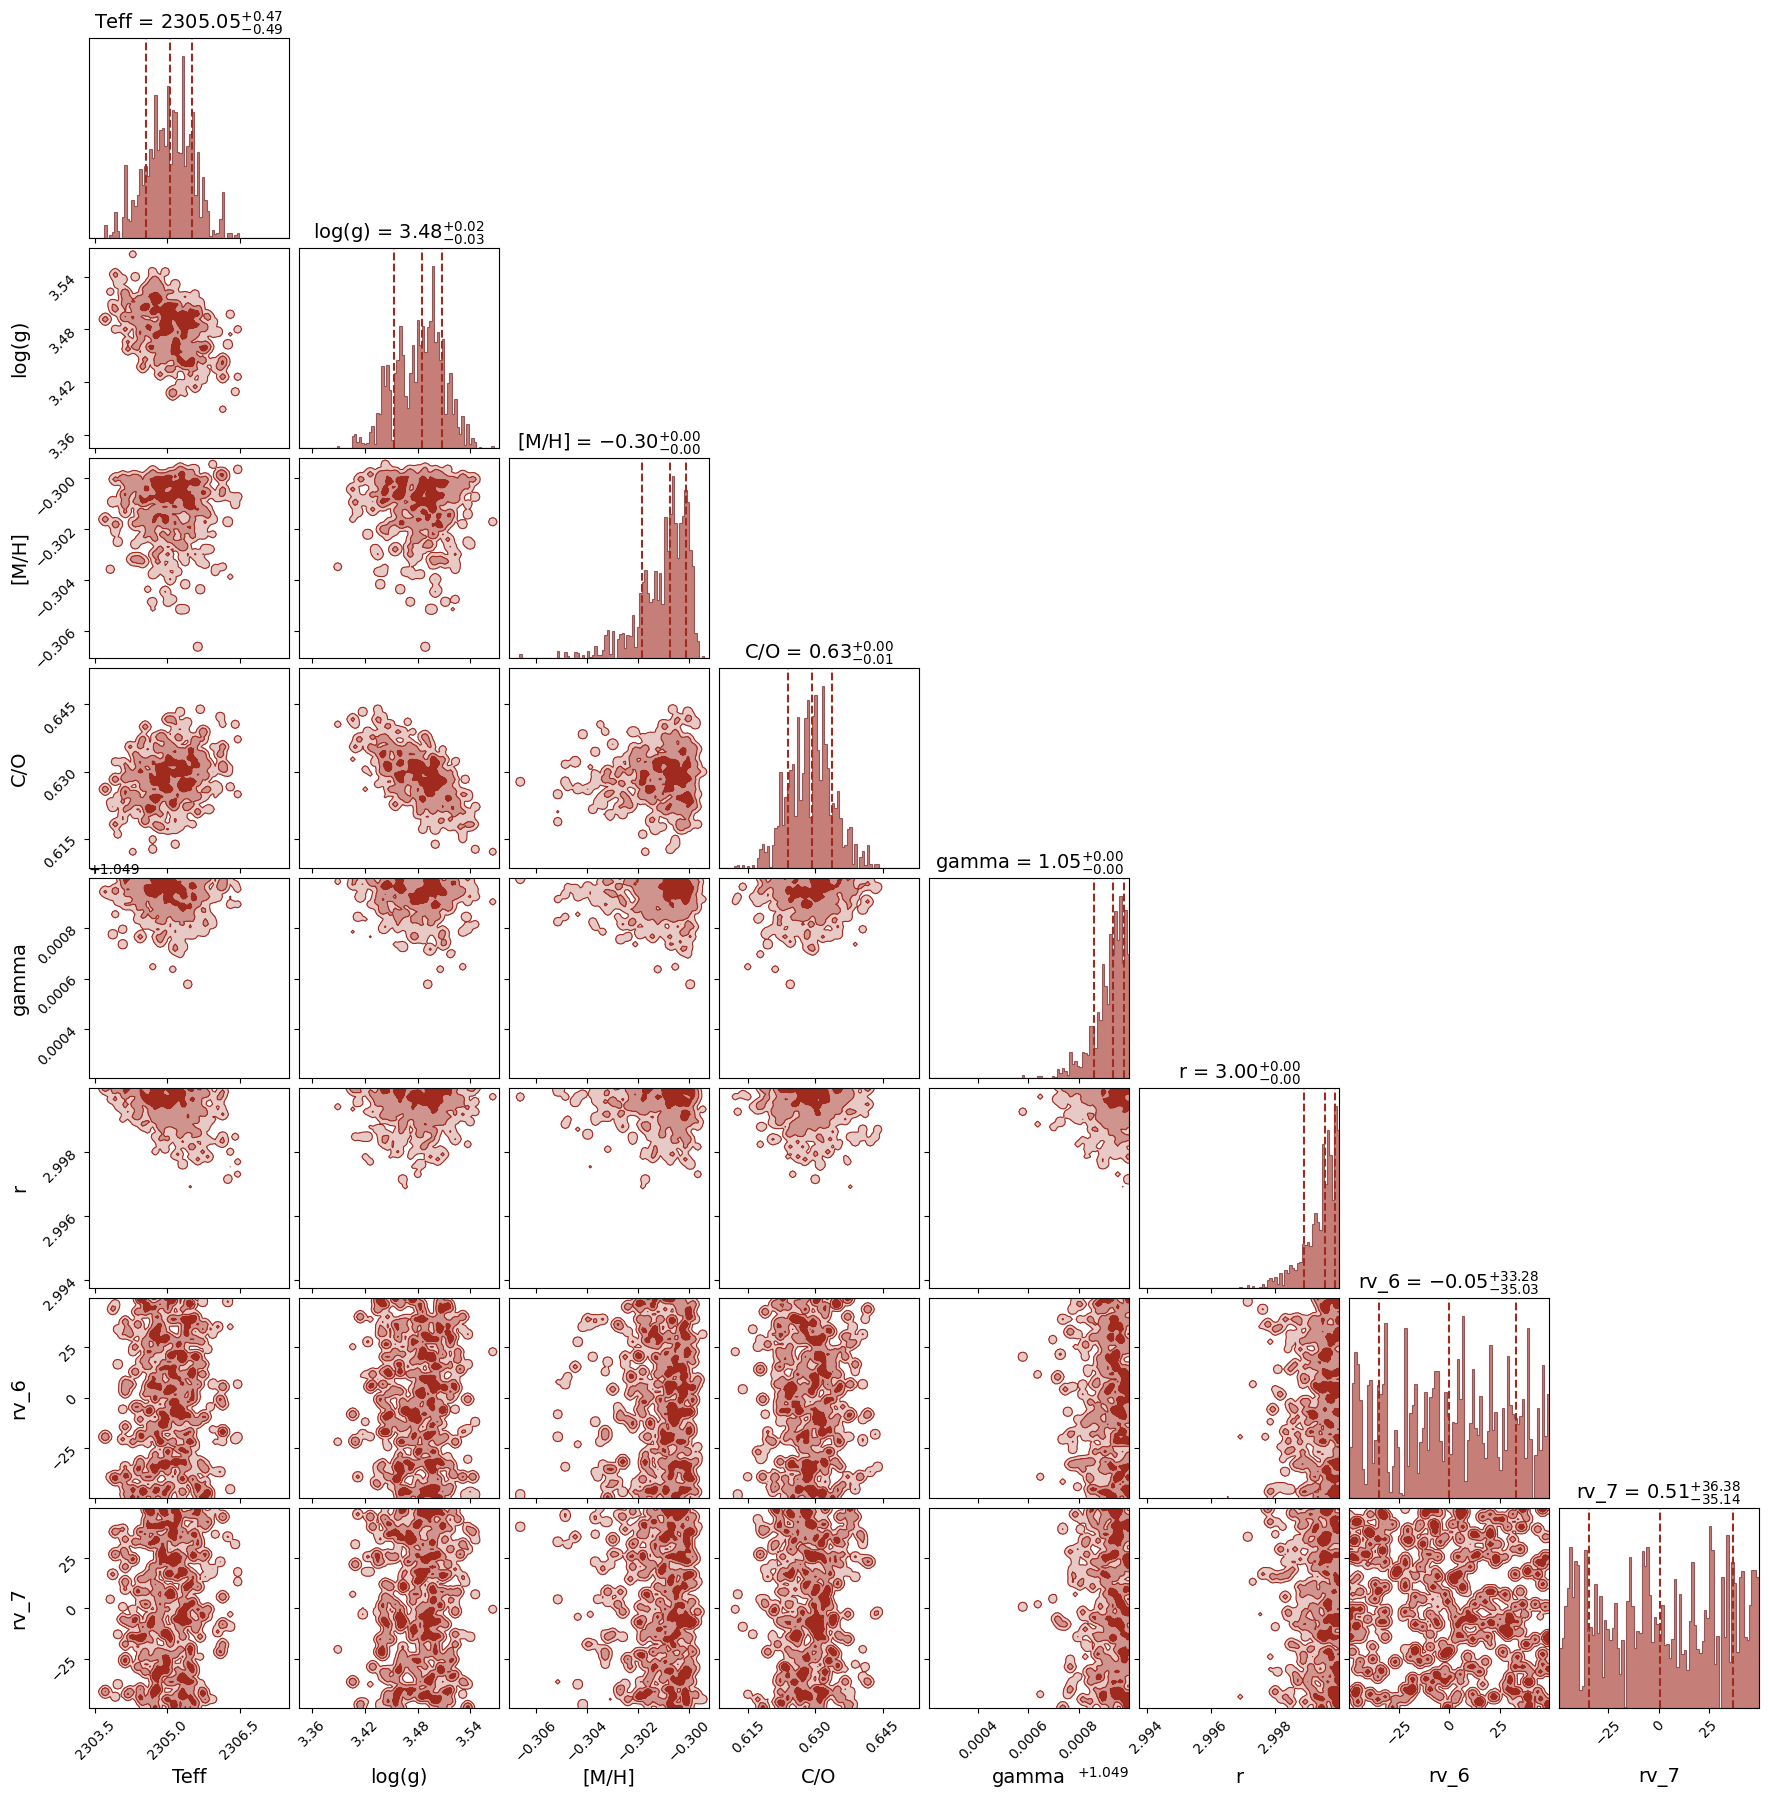

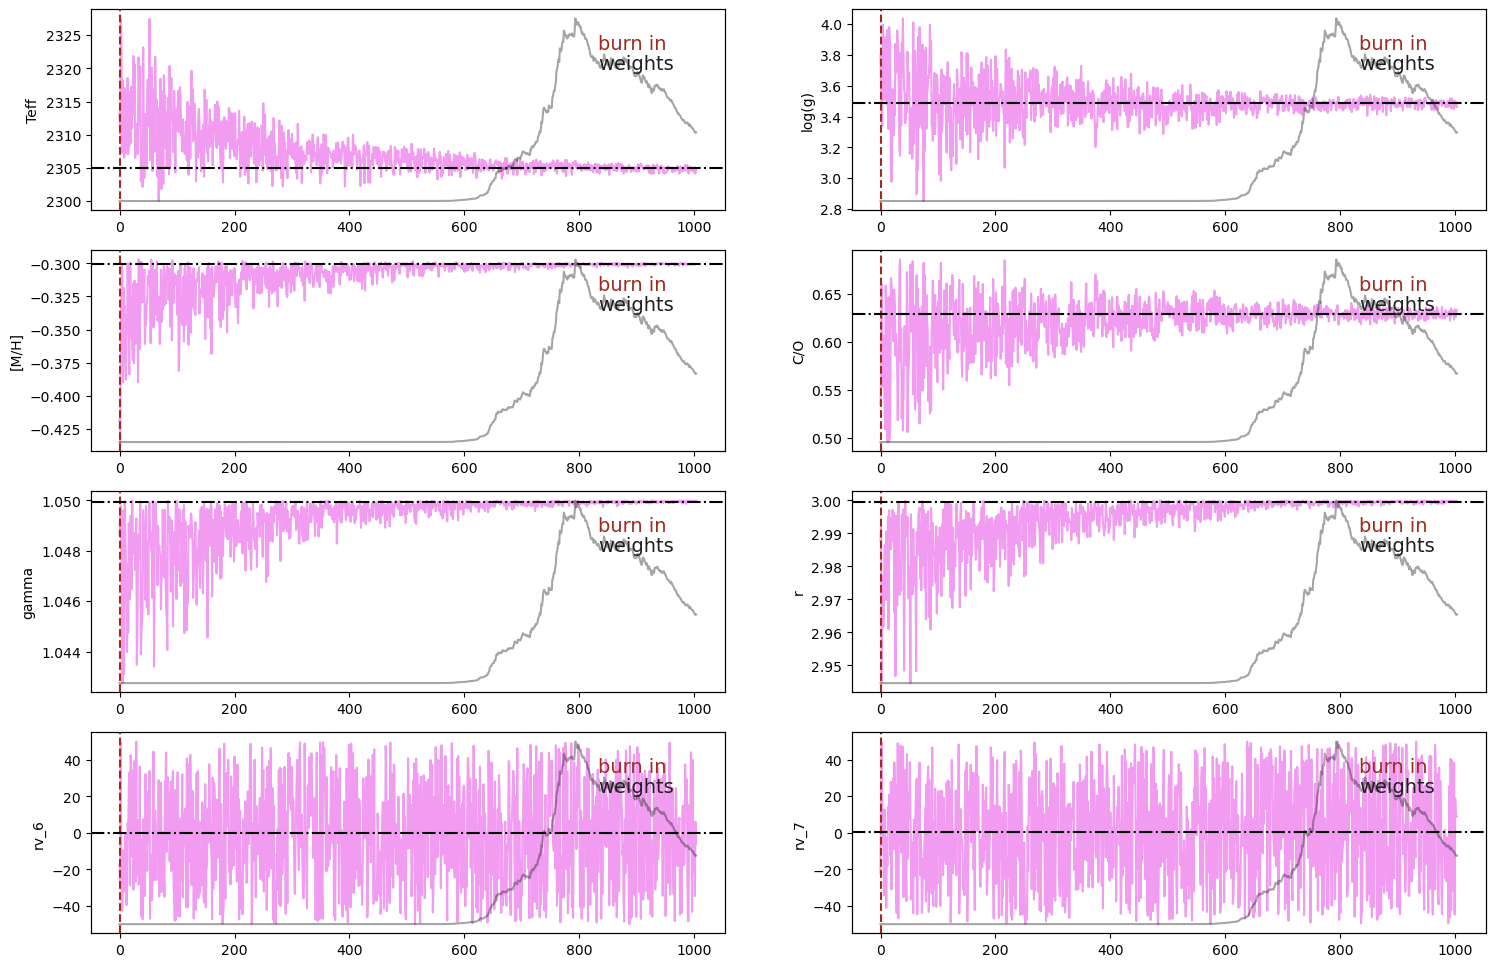

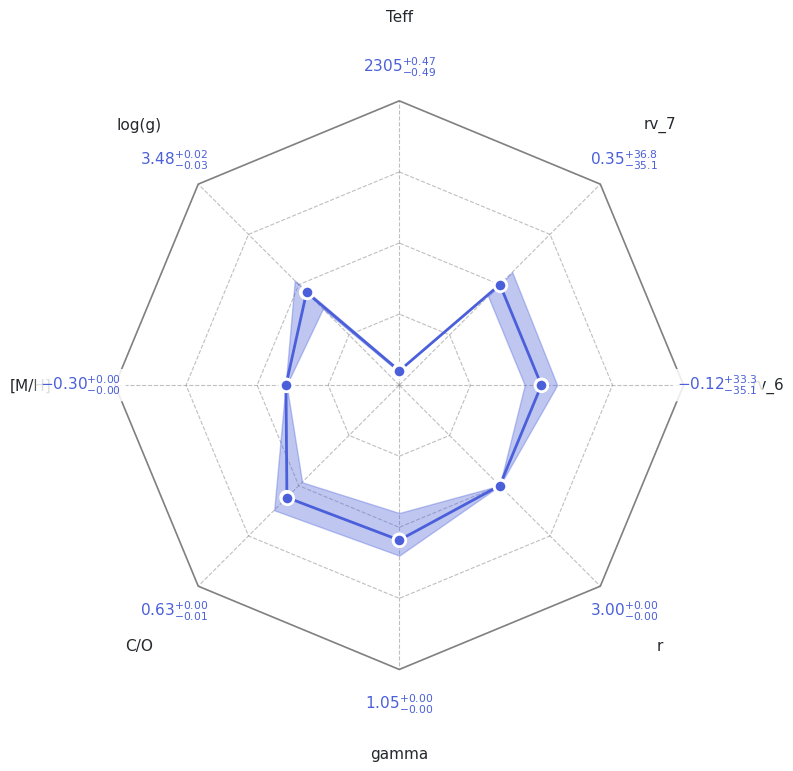

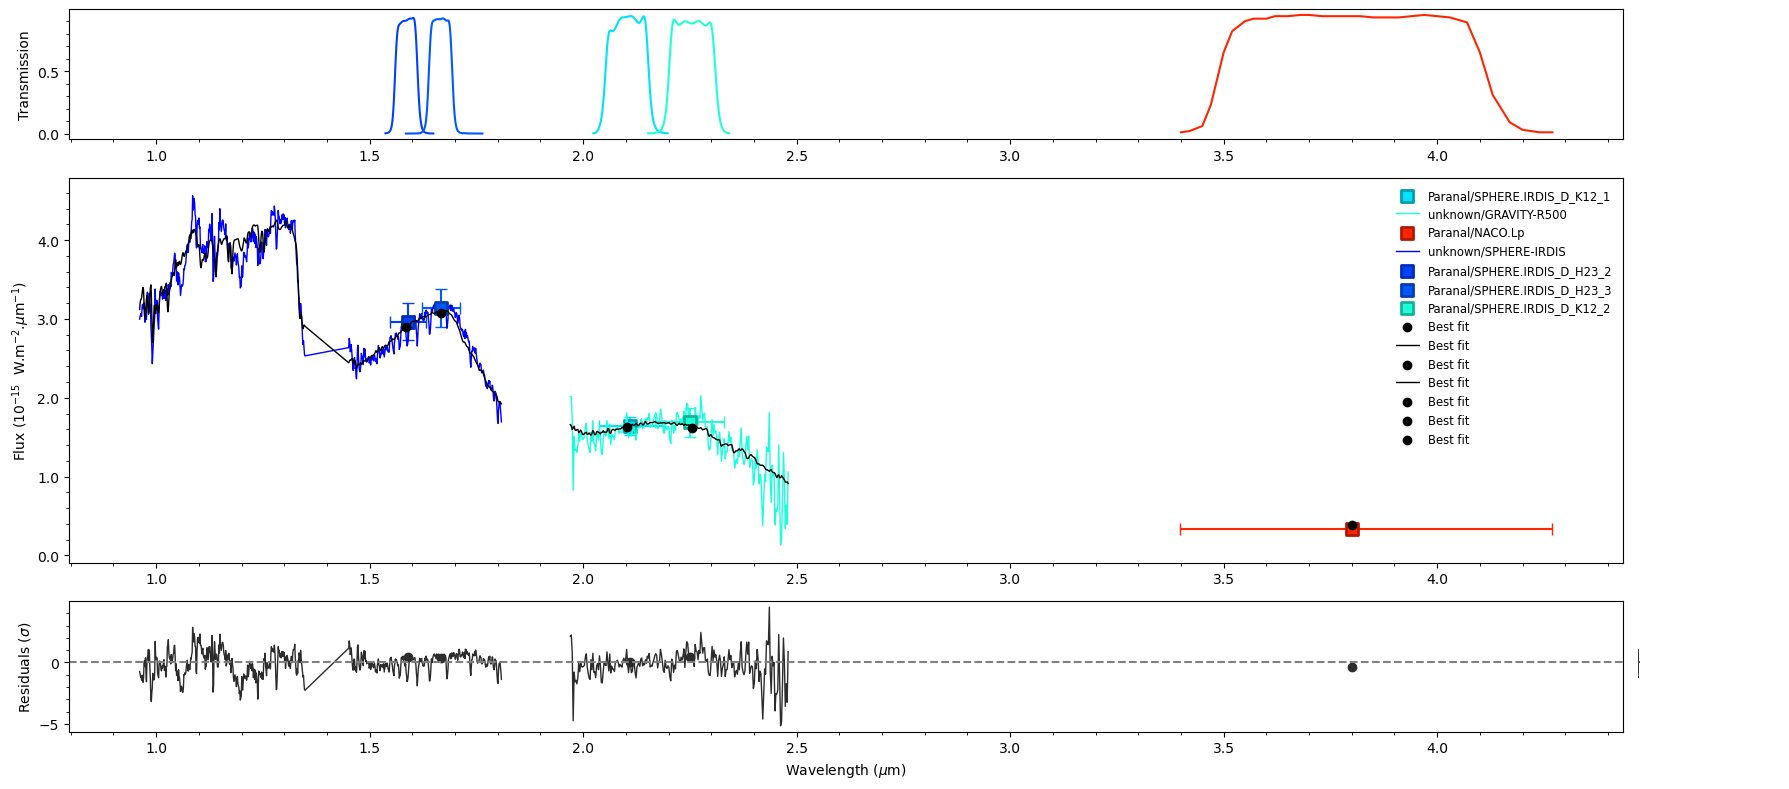

In [12]:
analysis.plot(analysis.ns.results)
print(analysis.ns.results.summary(sigma=1))

## Section 7: Next steps

- **Tutorial — HCHR mode (AF Lep b) [coming soon]:** VLT/HiRISE at R ≈ 140,000.
  Introduces `STAR_FLUX` extension, high-contrast modeling, and vsini.
- **Tutorial 4 — Advanced plotting:** Use the results from this (or Tutorial 2)
  to explore every ForMoSA plot in depth. No fitting required.
- **Tutorial 6 — Cluster / MPI deployment:** Scale up to 300+ live points
  using PyMultiNest on an HPC cluster.